[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Convolution over Images

The previous notebook ended with a design brief rather than a design: local receptive fields, and the same detector reused at every position.  This notebook builds the operation that satisfies it.

We will implement it in eight lines of Python, use it to detect edges by hand, and then *learn* that same edge detector from data — the transition from feature engineering to feature learning, in miniature.  At the end, once the operation is familiar, we return to the design brief and show something stronger than "this satisfies the principles": we show that nothing else could have.

In [15]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import torch
from torch import nn
import torch.nn.functional as F
from matplotlib import pyplot as plt

## The cross-correlation operation

Strictly speaking, "convolutional layer" is a misnomer: the operation these layers perform is **cross-correlation**.  We will return to the distinction at the end of the notebook; for now, let's see what the operation does.

Ignore channels and consider a two-dimensional input of height 3 and width 3 — shape $3 \times 3$ — and a kernel of height and width 2.  The shape of the *kernel window* (or *convolution window*) is given by the height and width of the kernel, here $2 \times 2$.

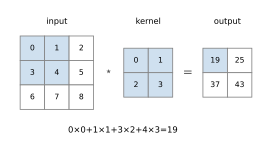

In [16]:
# this figure is drawn rather than linked, so the notebook needs no network
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')              # crisp vector output
except ImportError:
    pass

# Shared idiom for the grid figures of this module.  Geometry is in inches and
# the axes are set so one data unit is one inch, so text never outgrows a cell.
CELL = 0.34
SHADE = '#cfe0ef'          # cells taking part in the highlighted computation
SHADE2 = '#f3ddd0'         # a second, distinct computation
PAD_FILL = '0.955'         # padding added around the input
FS = 7.6

def _grid(ax, x0, y0, values, shade=(), shade2=(), pad=(), cell=CELL, fs=FS,
          colors=None, z=2):
    """Draw a matrix with its top-left cell's top-left corner at (x0, y0).

    `z` sets the drawing order, so overlapping channel slices occlude cleanly.
    """
    from matplotlib.patches import Rectangle
    shade, shade2, pad = set(shade), set(shade2), set(pad)
    colors = colors or {}
    for r, row in enumerate(values):
        for c, v in enumerate(row):
            fill = colors.get((r, c),
                              SHADE if (r, c) in shade else
                              SHADE2 if (r, c) in shade2 else
                              PAD_FILL if (r, c) in pad else 'white')
            ax.add_patch(Rectangle((x0 + c * cell, y0 - (r + 1) * cell),
                                   cell, cell, facecolor=fill,
                                   edgecolor='0.5', linewidth=0.8, zorder=z))
            if v is not None:
                ax.text(x0 + (c + 0.5) * cell, y0 - (r + 0.5) * cell, str(v),
                        ha='center', va='center', fontsize=fs,
                        color='0.55' if (r, c) in pad else 'black', zorder=z + 1)
    return len(values[0]) * cell, len(values) * cell


def _label(ax, x, y, text, fs=8.2, weight='normal'):
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, fontweight=weight)


def _op(ax, x, y, symbol):
    ax.text(x, y, symbol, ha='center', va='center', fontsize=12, color='0.35')


def _finish(fig, ax, x0, x1, y0, y1):
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.axis('off')
    fig.set_size_inches(x1 - x0, y1 - y0)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)


def _row_layout(panels, gap=0.42, top=0.0):
    """Left-to-right x positions for a row of (width, height) panels."""
    xs, cursor = [], 0.0
    for w, h in panels:
        xs.append(cursor)
        cursor += w + gap
    return xs, cursor - gap


# ---------------------------------------------------------------- 03_02 / 03_03

def cross_correlation_figure():
    """Input, kernel and output of a 2-D cross-correlation, with one window shaded."""
    X = [[0, 1, 2], [3, 4, 5], [6, 7, 8]]
    K = [[0, 1], [2, 3]]
    Y = [[19, 25], [37, 43]]

    fig, ax = plt.subplots()
    top = 0.0
    x = 0.0
    w1, h1 = _grid(ax, x, top, X, shade=[(0, 0), (0, 1), (1, 0), (1, 1)])
    _label(ax, x + w1 / 2, top + 0.20, 'input')
    x1 = x + w1
    _op(ax, x1 + 0.21, top - h1 / 2, r'$\star$')
    x2 = x1 + 0.42
    w2, h2 = _grid(ax, x2, top - (h1 - 2 * CELL) / 2, K,
                   shade=[(0, 0), (0, 1), (1, 0), (1, 1)])
    _label(ax, x2 + w2 / 2, top + 0.20, 'kernel')
    x3 = x2 + w2
    _op(ax, x3 + 0.21, top - h1 / 2, '=')
    x4 = x3 + 0.42
    w3, h3 = _grid(ax, x4, top - (h1 - 2 * CELL) / 2, Y, shade=[(0, 0)])
    _label(ax, x4 + w3 / 2, top + 0.20, 'output')

    ax.text((x4 + w3) / 2, top - h1 - 0.30,
            r'$0\times0 + 1\times1 + 3\times2 + 4\times3 = 19$',
            ha='center', va='center', fontsize=8.4)
    _finish(fig, ax, -0.18, x4 + w3 + 0.18, top - h1 - 0.52, top + 0.40)

cross_correlation_figure()

We begin with the window at the upper-left corner of the input and slide it across, left to right and top to bottom.  At each position, the input subtensor under the window and the kernel are multiplied elementwise and the products summed, yielding one scalar — one element of the output.  The first is

$$
0\times0+1\times1+3\times2+4\times3=19.
$$

Notice that the output is smaller than the input along each axis.  With a kernel wider or taller than one element, we can only place the window where it fits entirely inside the image, so an $n_\textrm{h} \times n_\textrm{w}$ input and a $k_\textrm{h} \times k_\textrm{w}$ kernel give an output of size

$$(n_\textrm{h}-k_\textrm{h}+1) \times (n_\textrm{w}-k_\textrm{w}+1).$$

The next notebook shows how to keep the size unchanged by padding the image with zeros around its boundary, giving the kernel room to shift.

Here is the whole operation.  Two loops over output positions, one elementwise product and sum inside — no more than that:

In [ ]:
def corr2d(X, K):
    """Compute the 2D cross-correlation of input X with kernel K."""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

Running it on the input and kernel from the figure should reproduce the figure's output:

In [ ]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
Y = corr2d(X, K)
print(Y)
assert torch.allclose(Y, torch.tensor([[19.0, 25.0], [37.0, 43.0]]))

### Checking against PyTorch

As elsewhere in the course, we verify our own implementation against the library's.  PyTorch's `F.conv2d` expects rank-4 tensors — `(batch, channels, height, width)` for the input and `(out_channels, in_channels, height, width)` for the kernel — so we add the two leading axes, call it, and strip them off again.  (Despite the name, `F.conv2d` also computes a cross-correlation; that is the convention throughout the framework.)

In [ ]:
theirs = F.conv2d(X.reshape(1, 1, *X.shape), K.reshape(1, 1, *K.shape))
print(theirs.reshape(Y.shape))
assert torch.allclose(Y, theirs.reshape(Y.shape))
print('match!')

## Convolutional layers

A convolutional layer cross-correlates its input with a kernel and adds a scalar bias.  Its two parameters are that kernel and that bias, and, exactly as with a fully connected layer, we initialize the kernel randomly and learn it.

Implementing the layer is now a matter of wrapping `corr2d` in a module.  In `__init__` we declare `weight` and `bias` as `nn.Parameter`s — the marker that tells PyTorch to track them for optimization — and `forward` calls `corr2d` and adds the bias:

In [ ]:
class Conv2D(nn.Module):
    """A two-dimensional convolutional layer, built from corr2d."""
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

A layer whose kernel has height $h$ and width $w$ is called an $h \times w$ convolutional layer, and its kernel an $h \times w$ convolution kernel.

## Edge detection, by hand

Let's put the operation to work.  We construct a $6 \times 8$ "image" whose middle four columns are black (0) and the rest white (1):

In [ ]:
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

Now a kernel of height 1 and width 2 containing $[1, -1]$.  Applied to a pair of horizontally adjacent pixels it outputs zero when they are equal and something nonzero when they differ.

It is worth seeing this kernel for what it is: a **finite difference operator**.  At location $(i,j)$ it computes $x_{i,j} - x_{i,j+1}$, a discrete approximation to the derivative in the horizontal direction — recall that $\partial_i f(i,j) = \lim_{\epsilon \to 0} \frac{f(i,j) - f(i+\epsilon,j)}{\epsilon}$.  An edge is a place where the image changes quickly, so a derivative is exactly the right thing to measure.

In [ ]:
K = torch.tensor([[1.0, -1.0]])

In [ ]:
Y = corr2d(X, K)
Y

The output is $1$ at the white-to-black edge, $-1$ at the black-to-white edge, and $0$ everywhere else.  The detector works — but only in one direction.  Transposing the image turns the vertical edges into horizontal ones, and the response vanishes:

In [ ]:
corr2d(X.t(), K)

This is a first glimpse of why we will want many kernels per layer rather than one: a single kernel detects a single kind of local structure, at a single orientation.  Notebook 4 makes that concrete as *channels*.

## Learning a kernel

Designing an edge detector as a finite difference is neat, and for decades this was how computer vision worked: experts hand-crafted filters, and the quality of a system depended on the quality of their intuitions.  It does not scale.  For larger kernels, and for the second and third layer of a network operating on the outputs of the first, nobody can say what the filter *should* be.

So let's learn it instead.  We have the input `X` and the desired output `Y`; can we recover the kernel that maps one to the other, from the input–output pair alone?  We build a convolutional layer with a randomly initialized $1 \times 2$ kernel and run gradient descent on the squared error between its output and `Y`.

This time we use PyTorch's own `nn.LazyConv2d` rather than our `Conv2D` — "lazy" because it infers the number of input channels the first time it sees data, so we need only state the number of *output* channels.  We drop the bias to keep the picture clean.

In [ ]:
# a convolutional layer with 1 output channel and a kernel of shape (1, 2);
# for simplicity we ignore the bias
conv2d = nn.LazyConv2d(1, kernel_size=(1, 2), bias=False)

# convolutional layers work on four-dimensional tensors of shape
# (example, channel, height, width); here batch size and channels are both 1
X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
lr = 3e-2  # learning rate

for i in range(20):
    Y_hat = conv2d(X)
    loss = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    loss.sum().backward()
    # update the kernel by hand rather than through an optimizer
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 4 == 0:
        print(f'epoch {i + 1}, loss {loss.sum():.3f}')

The error is near zero after twenty iterations.  What did it learn?

In [ ]:
learned = conv2d.weight.data.reshape((1, 2))
print(learned)
assert torch.allclose(learned, K, atol=5e-2)

Close to $[1, -1]$ — the kernel we designed by hand, recovered from data.  The example is small enough to be checked by eye, but the principle is the entire premise of deep computer vision: **we do not design the filters, we specify the architecture and let the data choose them.**

## Cross-correlation and convolution

We have been calling this operation a convolution while admitting that it is really a cross-correlation.  Time to settle the debt — and the whole of the difference fits in one picture.

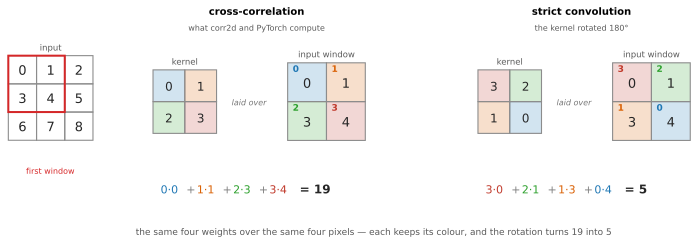

In [17]:
from matplotlib.patches import Rectangle

INK = '0.15'
WCOL = ['#1f77b4', '#d95f02', '#2ca02c', '#c0392b']    # one colour per weight

grid_X = [[0, 1, 2], [3, 4, 5], [6, 7, 8]]   # the input from the top of the notebook
window = [[0, 1], [3, 4]]                    # its first 2 x 2 window
kernel = [[0, 1], [2, 3]]
rotated = [[3, 2], [1, 0]]                   # the same kernel, turned 180 degrees

def draw_cells(ax, values, tints=None, corner=False, fs=13):
    # a grid of cells: value in the centre, kernel weight small in the corner
    n, m = len(values), len(values[0])
    ax.set_xlim(-0.04, m + 0.04); ax.set_ylim(n + 0.04, -0.04)
    ax.set_aspect('equal'); ax.axis('off')
    for i in range(n):
        for j in range(m):
            if tints:
                ax.add_patch(Rectangle((j, i), 1, 1, alpha=0.20,
                                       facecolor=WCOL[tints[i][j]],
                                       edgecolor='none'))
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False,
                                   edgecolor='0.55', lw=1.1))
            ax.text(j + 0.5, i + 0.55, f'{values[i][j]:g}', ha='center',
                    va='center', fontsize=fs, color=INK)
            if corner:
                ax.text(j + 0.13, i + 0.17, f'{tints[i][j]:g}', ha='left',
                        va='center', fontsize=9, fontweight='bold',
                        color=WCOL[tints[i][j]])

def draw_panel(fig, x0, title, note, weights):
    # one convention: the kernel as laid down, the window, and the arithmetic
    fig.text(x0 + 0.155, 0.95, title, ha='center', fontsize=10,
             fontweight='bold')
    fig.text(x0 + 0.155, 0.885, note, ha='center', fontsize=8, color='0.35')

    ax = fig.add_axes([x0 + 0.01, 0.46, 0.10, 0.27])
    draw_cells(ax, weights, tints=weights, fs=12)
    ax.set_title('kernel', fontsize=8.5, color='0.35', pad=4)

    fig.text(x0 + 0.145, 0.58, 'laid over', ha='center', fontsize=8,
             color='0.45', style='italic')

    ax = fig.add_axes([x0 + 0.185, 0.43, 0.125, 0.33])
    draw_cells(ax, window, tints=weights, corner=True)
    ax.set_title('input window', fontsize=8.5, color='0.35', pad=4)

    x, total = x0 + 0.028, 0
    for k, (i, j) in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)]):
        w, v = weights[i][j], window[i][j]
        total += w * v
        fig.text(x, 0.22, f'{w:g}·{v:g}', fontsize=11, color=WCOL[w])
        x += 0.048
        if k < 3:
            fig.text(x - 0.014, 0.22, '+', fontsize=11, color='0.5')
    fig.text(x - 0.008, 0.22, f'= {total:g}', fontsize=12, color=INK,
             fontweight='bold')

fig = plt.figure(figsize=(10.5, 3.4))
ax = fig.add_axes([0.015, 0.40, 0.115, 0.42])
draw_cells(ax, grid_X)
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='C3', lw=2.0))
ax.set_title('input', fontsize=8.5, color='0.35', pad=4)
fig.text(0.072, 0.30, 'first window', ha='center', fontsize=8, color='C3')

draw_panel(fig, 0.19, 'cross-correlation', 'what corr2d and PyTorch compute',
           kernel)
draw_panel(fig, 0.62, 'strict convolution', 'the kernel rotated 180°', rotated)

fig.text(0.5, 0.05, 'the same four weights over the same four pixels — each '
         'keeps its colour, and the rotation turns 19 into 5',
         ha='center', fontsize=9, color='0.35');

Both panels use the same four pixels and the same four weights.  The only thing that changes is *which weight lands on which pixel*: strict convolution turns the kernel through 180° before laying it down, so the weight that sat at the top left ends up at the bottom right.  For this fixed kernel the two conventions give different answers, 19 against 5.

For the record, the formal definitions.  In mathematics the convolution of two functions $f, g: \mathbb{R}^d \to \mathbb{R}$ is

$$(f * g)(\mathbf{x}) = \int f(\mathbf{z}) g(\mathbf{x}-\mathbf{z}) \, d\mathbf{z},$$

the overlap between $f$ and $g$ when one is flipped and shifted by $\mathbf{x}$.  For discrete objects the integral becomes a sum,

$$(f * g)(i) = \sum_a f(a) g(i-a),$$

and in two dimensions,

$$(f * g)(i, j) = \sum_a\sum_b f(a, b) g(i-a, j-b).$$

Note the *difference* $(i-a, j-b)$ where `corr2d` uses the *sum* $(i+a, j+b)$.  That index reversal is precisely the rotation in the figure.

### Why the flip is there at all

If the flip only decides which weight goes where, why does mathematics insist on it?  Because it is what makes convolution **commutative**: $f * g = g * f$.  Cross-correlation has no such property.  The cleanest way to see this is in one dimension, where a convolution is short enough to write as a double loop:

In [18]:
def conv1d(f, g):
    """Strict convolution of two 1-D signals, over their full support."""
    out = torch.zeros(len(f) + len(g) - 1)
    for i in range(len(f)):
        for j in range(len(g)):
            out[i + j] += f[i] * g[j]      # note: i + j, symmetric in f and g
    return out

def corr1d(f, g):
    """Cross-correlation: g slides over f without being flipped."""
    return conv1d(f, torch.flip(g, dims=(0,)))

f = torch.tensor([1.0, 2.0, 3.0])
g = torch.tensor([0.0, 1.0, 0.5])

print('conv(f, g) =', conv1d(f, g).tolist())
print('conv(g, f) =', conv1d(g, f).tolist())
assert torch.allclose(conv1d(f, g), conv1d(g, f))
print('convolution commutes\n')

print('corr(f, g) =', corr1d(f, g).tolist())
print('corr(g, f) =', corr1d(g, f).tolist())
assert not torch.allclose(corr1d(f, g), corr1d(g, f))
# swapping the arguments does not give nonsense -- it reverses the answer
assert torch.allclose(corr1d(f, g), torch.flip(corr1d(g, f), dims=(0,)))
print('cross-correlation does not commute: swapping the arguments '
      'reverses the result')

conv(f, g) = [0.0, 1.0, 2.5, 4.0, 1.5]
conv(g, f) = [0.0, 1.0, 2.5, 4.0, 1.5]
convolution commutes

corr(f, g) = [0.5, 2.0, 3.5, 3.0, 0.0]
corr(g, f) = [0.0, 3.0, 3.5, 2.0, 0.5]
cross-correlation does not commute: swapping the arguments reverses the result


Look at the index in `conv1d`: the output position is `i + j`, which treats `f` and `g` symmetrically, so exchanging them cannot change the answer.  `corr1d` breaks that symmetry by flipping one argument first.

Commutativity, and the associativity that comes with it, are the reason convolution is *the* natural operation in signal processing.  They give the convolution theorem — convolution in one domain is multiplication in the other — and they let a cascade of linear time-invariant systems be collapsed into a single equivalent filter, in any order you please.  If you have met convolution in a signals course, this is why the flip was presented as essential.

### Why deep learning does not care

Here is the point: because the kernel is *learned*, none of that matters.  Suppose a cross-correlation layer learns kernel $\mathbf{K}$.  A strict-convolution layer trained on the same data would simply learn the rotated version of $\mathbf{K}$ — the right-hand panel of the figure — and produce exactly the same output.  The two parametrizations reach the same function class; only the arrangement of numbers in memory differs.  Nobody needs $f * g = g * f$ when $g$ is chosen by gradient descent.

## Feature maps and receptive fields

Two pieces of vocabulary that will recur for the rest of the module.

The output of a convolutional layer is often called a **feature map**: it is a learned representation (a set of features) that is still laid out spatially, so it can be fed to another convolutional layer.

For any element $x$ in some layer, its **receptive field** is the set of all elements, in all previous layers, that can affect the computation of $x$.  Note that it may be larger than the input.

Use the figure at the top of the notebook.  With a $2 \times 2$ kernel, the receptive field of the shaded output element (value 19) is the four shaded input elements.  Now stack: call that $2 \times 2$ output $\mathbf{Y}$, and add a second $2 \times 2$ convolutional layer producing a single element $z$.  The receptive field of $z$ on $\mathbf{Y}$ is all four of its elements — and on the *input* it is all nine.  Depth buys reach.  When a feature needs to see a larger region than one kernel covers, the answer is another layer.

In [ ]:
# receptive field growth with depth: k x k kernels, stride 1
def receptive_field(num_layers, k=3):
    """Side length of the receptive field after `num_layers` k x k layers."""
    return 1 + num_layers * (k - 1)

for layers in range(1, 9):
    print(f'{layers} layers of 3x3 -> receptive field '
          f'{receptive_field(layers)}x{receptive_field(layers)}')

Notice how slowly this grows: reaching across a $224 \times 224$ image with $3\times3$ layers alone would take over a hundred of them.  Notebooks 3 and 5 introduce the two devices — strided convolution and pooling — that make the receptive field grow *multiplicatively* instead.

The term "receptive field" is borrowed from neurophysiology.  Hubel and Wiesel's experiments on the visual cortex found that lower levels respond to edges and simple shapes.  Field (1987) illustrated the effect on natural images with what can only be called convolution kernels:

![Figure and caption taken from Field (1987): An example of coding with six different channels. (Left) Examples of the six types of sensor associated with each channel. (Right) Convolution of the image in (Middle) with the six sensors shown in (Left). The response of the individual sensors is determined by sampling these filtered images at a distance proportional to the size of the sensor (shown with dots). This diagram shows the response of only the even symmetric sensors.](https://github.com/d2l-ai/d2l-en/raw/refs/heads/master/img/field-visual.png)

The correspondence is not limited to the first layer: [Kuzovkin et al. (2018)](https://www.nature.com/articles/s42003-018-0110-y) found that activity in deep CNNs captures essential characteristics of biological object recognition.

## Where convolution comes from

We have been treating the sliding window as a reasonable thing to try.  It is time to show that it is not merely reasonable — given the two principles from the last notebook, it is the *only* option.  This is the most mathematical passage in the module, and it repays the effort: it explains why an operation invented for one purpose keeps turning out to be the right one.

Start with a fully connected layer, but refuse to flatten.  Let the input $\mathbf{X}$ be a two-dimensional image, and insist that the hidden representation $\mathbf{H}$ be two-dimensional as well, of the same shape — so that "the unit at position $(i,j)$" is a meaningful phrase on both sides.  Let that sink in: we are asking the hidden layer to keep the spatial layout, not just the input.

Writing $[\mathbf{X}]_{i, j}$ and $[\mathbf{H}]_{i, j}$ for the values at location $(i,j)$, connecting every hidden unit to every input pixel now needs, instead of a weight *matrix*, a fourth-order weight *tensor* $\mathsf{W}$.  With $\mathbf{U}$ holding the biases:

$$\begin{aligned} \left[\mathbf{H}\right]_{i, j} &= [\mathbf{U}]_{i, j} + \sum_k \sum_l[\mathsf{W}]_{i, j, k, l}  [\mathbf{X}]_{k, l}\\ &=  [\mathbf{U}]_{i, j} +
\sum_a \sum_b [\mathsf{V}]_{i, j, a, b}  [\mathbf{X}]_{i+a, j+b}.\end{aligned}$$

The second line is the first line rewritten, nothing more.  We re-indexed the source pixel by its *offset* from $(i,j)$ instead of its absolute position, substituting $k = i+a$ and $l = j+b$, so that $[\mathsf{V}]_{i, j, a, b} = [\mathsf{W}]_{i, j, i+a, j+b}$.  The offsets $a$ and $b$ run over positive and negative values, covering the whole image.  This change of variables is the only trick in the derivation, and it is worth understanding why we bothered: the principles we want to impose are statements about *offsets*, and they are invisible in the first line.

Before continuing, count.  A $1000 \times 1000$ image mapped to a $1000 \times 1000$ hidden representation needs $10^{12}$ parameters — the fully connected disaster of notebook 1, in its most general form.

### Imposing translation invariance

Our first principle says that shifting the input should simply shift the hidden representation.  Suppose the network's response to a patch at the top left differed from its response to the same patch at the bottom right; then $\mathsf{V}$ would have to depend on *where* we are, $(i, j)$, and not just on the offset.  Translation invariance is precisely the demand that it does not:

$$[\mathsf{V}]_{i, j, a, b} = [\mathbf{V}]_{a, b},$$

with the bias likewise a single constant $u$.  Substituting:

$$[\mathbf{H}]_{i, j} = u + \sum_a\sum_b [\mathbf{V}]_{a, b}  [\mathbf{X}]_{i+a, j+b}.$$

**Look at what we have written.**  This is `corr2d`.  The nested sum over offsets $a, b$ with position-independent weights $[\mathbf{V}]_{a, b}$ is exactly the nested loop from the top of this notebook, and $\mathbf{V}$ is exactly the kernel `K`.  We did not choose a sliding window; we asked for translation invariance and were handed one.

The count falls to about $4 \times 10^6$: no dependence on position, though still on every offset $a, b \in (-1000, 1000)$.

### Imposing locality

The second principle says that assessing what is happening at $(i,j)$ should not require consulting pixels far away.  In the notation, that means the weights vanish beyond some range: $[\mathbf{V}]_{a, b} = 0$ whenever $|a| > \Delta$ or $|b| > \Delta$.  Terms that are zero can be dropped from the sum:

$$[\mathbf{H}]_{i, j} = u + \sum_{a = -\Delta}^{\Delta} \sum_{b = -\Delta}^{\Delta} [\mathbf{V}]_{a, b}  [\mathbf{X}]_{i+a, j+b}.$$

This is a **convolutional layer**, in full, and $\mathbf{V}$ is its *kernel*, *filter*, or simply its learnable weights.  The count falls from $4 \times 10^6$ to $4\Delta^2$, and $\Delta$ is rarely larger than a handful — for the $5 \times 5$ kernels we use later, 25 numbers.

Take stock of the whole journey.  A single layer that would have cost $10^{12}$ parameters costs a few hundred, and the dimensions of the input and the hidden representation have not changed at all.  Nothing was approximated; we simply refused to let the layer use parameters that the two principles say it should not have.

### What it costs

Nothing is free.  We have bought this reduction by *constraining the function class*: a convolutional layer cannot express a function whose response varies with position, and cannot express one that depends on distant pixels jointly within a single layer.

This is an **inductive bias** — an assumption built into the architecture rather than learned from data.  All learning depends on imposing some bias, and the calculation is always the same: when the bias matches reality, we get sample-efficient models that generalize from little data; when it does not, the model may struggle to fit even its training set.  Here we are betting that the statistics of natural images really are roughly translation invariant and locally structured.  That bet is what the whole field rests on, and it has paid handsomely — but it is a bet, and notebook 1's exercise about tasks where absolute position matters is a reminder of when it fails.

The two constraints also explain the shape of everything that follows in this module.  Because a single layer sees only a $\Delta$-neighborhood, reach must come from *depth* — hence the receptive-field arithmetic above, and hence pooling and strides in notebooks 3 and 5.  And because a single kernel computes a single feature everywhere, expressiveness must come from having *many* kernels — hence channels in notebook 4.  Every remaining topic in the module is a consequence of the two lines of algebra above.

## Summary

* The core computation of a convolutional layer is a cross-correlation: slide a window over the input, multiply elementwise by the kernel, sum.  A nested loop is all it takes to express, and our implementation agrees with PyTorch's `F.conv2d`.
* The computation is highly **local**, which is what allows the aggressive hardware optimization that modern computer vision depends on.
* Convolution kernels detect local structure — a $[1, -1]$ kernel is a finite difference operator and detects vertical edges.  One kernel detects one kind of structure, which is the motivation for having many.
* We do not need to invent good filters: gradient descent recovers the edge detector from input–output pairs alone.  Feature engineering is replaced by feature learning.
* Cross-correlation and strict convolution differ by a 180° rotation of the kernel.  The rotation is what makes convolution commutative, which is why signal processing insists on it — and why deep learning, whose kernels are learned, does not.
* Convolution is not a heuristic.  Imposing **translation invariance** on a fully connected layer over an image forces its weights to depend only on the offset between input and output positions — which *is* `corr2d` — and imposing **locality** shrinks the kernel to a small window.  Together they take one layer from $10^{12}$ parameters to a few hundred.
* The price is an inductive bias: a convolutional layer cannot represent position-dependent or long-range behaviour within a single layer.  Reach therefore comes from depth, and expressiveness from having many kernels — which is the agenda for the rest of the module.
* An output element's **receptive field** is everything that can influence it.  It grows with depth, which is why deep networks can respond to large-scale structure built from small kernels.

## Exercises

1. Construct an image `X` with diagonal edges.  What happens if you apply the kernel `K` from this notebook to it?  What if you transpose `X`?  What if you transpose `K`?
2. Design a kernel that detects horizontal edges, and one that responds to a corner.  Verify them on images you construct.
3. When you try to automatically find the gradient for the `Conv2D` class we created, what kind of error message do you see?  (Hint: pass it a rank-2 tensor and then a rank-4 one.)
4. How would you represent a cross-correlation operation as a matrix multiplication by changing the input and kernel tensors?  What does the resulting matrix look like — how many of its entries are zero, and how many distinct values does it contain?
5. Rerun the kernel-learning experiment with a $2 \times 2$ kernel instead of $1 \times 2$.  Does it still recover something that acts as an edge detector?  Is the solution unique?
6. Take one Fashion-MNIST image from notebook 1 and apply the $[1, -1]$ kernel and its transpose to it.  Plot both feature maps.  What is each one responding to?
7. In the derivation, we imposed translation invariance *before* locality.  Redo it in the other order: first restrict the weights to a $\Delta$-neighborhood, then require position-independence.  Do you arrive at the same layer?  What is the parameter count after each step, and why do the intermediate numbers differ?
8. Suppose we impose locality but *not* translation invariance — every position gets its own $3 \times 3$ kernel.  This is a real architecture, sometimes called a locally connected layer.  How many parameters does it need for a $28 \times 28$ image?  When might it be preferable to a convolution?  (Hint: think about images that are always framed the same way, such as aligned faces.)